# Практическое занятие №2 — Исследовательский анализ данных (EDA) и визуализация зависимостей

**Дисциплина:** Машинное обучение (Machine Learning)  
**Уровень:** Практикум / Базовый  
**Автор:** Осинцев Артем Викторович

---

## 1. Введение в EDA (Exploratory Data Analysis)
Исследовательский анализ данных — это критический этап перед построением моделей. По оценкам индустрии, до 80% времени проекта уходит на подготовку и понимание данных. Цель EDA — не просто построить графики, а сформулировать гипотезы, обнаружить аномалии и понять структуру данных.

**Ключевые вопросы EDA:**
1.  **Качество данных:** Есть ли пропуски? Есть ли выбросы?
2.  **Распределения:** Нормальное ли распределение у признаков? Есть ли перекос (skewness)?
3.  **Зависимости:** Какие признаки коррелируют с целевой переменной? Есть ли мультиколлинеарность?
4.  **Типы данных:** Какие признаки категориальные, какие численные?

> **Академическое замечание:** Всегда документируйте свои шаги. Ноутбук должен быть рассказом (storytelling) о данных, а не просто набором кода.












---

## 2. Теоретический базис методов

### 2.1. Пропущенные значения (Missing Values)
*   **MCAR (Missing Completely At Random):** Пропуск не зависит ни от чего.
*   **MAR (Missing At Random):** Пропуск зависит от других наблюдаемых переменных.
*   **MNAR (Missing Not At Random):** Пропуск зависит от самого пропущенного значения.
*   **Стратегии заполнения:**
    *   *Среднее (Mean):* Для нормальных распределений. Чувствительно к выбросам.
    *   *Медиана (Median):* Для распределений с выбросами.
    *   *Мода (Mode):* Для категориальных данных.

### 2.2. Выбросы (Outliers)
*   **IQR (Interquartile Range):** Метод межквартильного размаха. Выбросы за пределами $[Q1 - 1.5 \cdot IQR, Q3 + 1.5 \cdot IQR]$. Не требует предположения о нормальности.
*   **Z-Score:** Количество стандартных отклонений от среднего. Обычно порог $|Z| > 3$. Работает хорошо для нормальных распределений.

### 2.3. Преобразование признаков
*   **Логарифмирование:** Уменьшает правосторонний перекос (right skew).
*   **Нормализация (MinMax):** Приводит к диапазону $[0, 1]$.
*   **Стандартизация (Z-score):** Приводит к $\mu=0, \sigma=1$.

---

## 3. Практическая демонстрация

В данном примере мы используем датасет **California Housing** (из библиотеки `sklearn`). Поскольку он достаточно чистый, мы **искусственно создадим** пропуски и категориальные признаки, чтобы продемонстрировать все требуемые методы анализа.

> **Инструкция:** Скопируйте код по очереди в ячейки Jupyter Notebook в Google Colab.

### Блок 1: Подготовка данных и имитация проблем

## Какую проблему решаем
> Проблема: Реальные данные редко бывают идеальными. Этот блок создаёт контролируемую учебную среду с известными проблемами (пропуски, выбросы, категории), чтобы мы могли отработать методы их обнаружения и обработки.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import missingno as msno  # Библиотека для визуализации пропусков

# Установка библиотеки missingno для Colab
!pip install missingno -q

# Загрузка данных
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['Target'] = california.target

# --- Имитация проблем для учебных целей ---
np.random.seed(42)

# 1. Создаем пропуски (5% случайно)
missing_cols = ['AveRooms', 'AveBedrms', 'Population']
for col in missing_cols:
    mask = np.random.choice([True, False], size=len(df), p=[0.05, 0.95])
    df.loc[mask, col] = np.nan

# 2. Создаем категориальный признак (возраст дома)
df['HouseAgeCat'] = pd.cut(df['HouseAge'], bins=[0, 10, 30, 50, 100], labels=['New', 'Medium', 'Old', 'VeryOld'])

# 3. Создаем выбросы в целевой переменной
df.loc[np.random.choice(df.index, 10), 'Target'] = df['Target'].max() * 5

print(f"Размер датасета: {df.shape}")
print(f"Пропуски:\n{df.isnull().sum()}")

Размер датасета: (20640, 10)
Пропуски:
MedInc            0
HouseAge          0
AveRooms       1018
AveBedrms      1023
Population     1034
AveOccup          0
Latitude          0
Longitude         0
Target            0
HouseAgeCat       0
dtype: int64


### Блок 2: Визуализация пропусков и заполнение

## Какую проблему решаем
>Проблема: Большинство алгоритмов ML не работают с пропусками. Неправильное заполнение может внести смещение (Bias) в модель. Мы выбираем медиану, потому что она минимизирует влияние выбросов на оценку центральной тенденции, что соответствует принципу робастности из теории вероятностей.

<Figure size 1000x500 with 0 Axes>

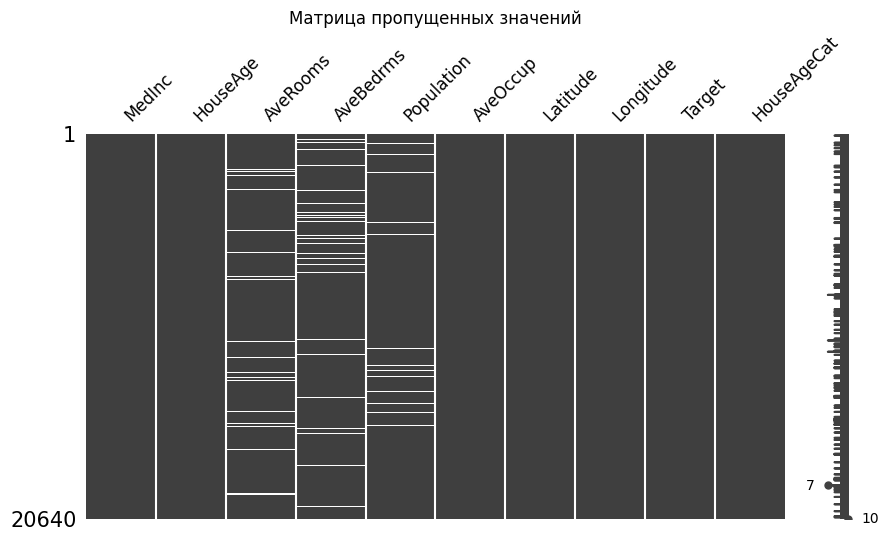

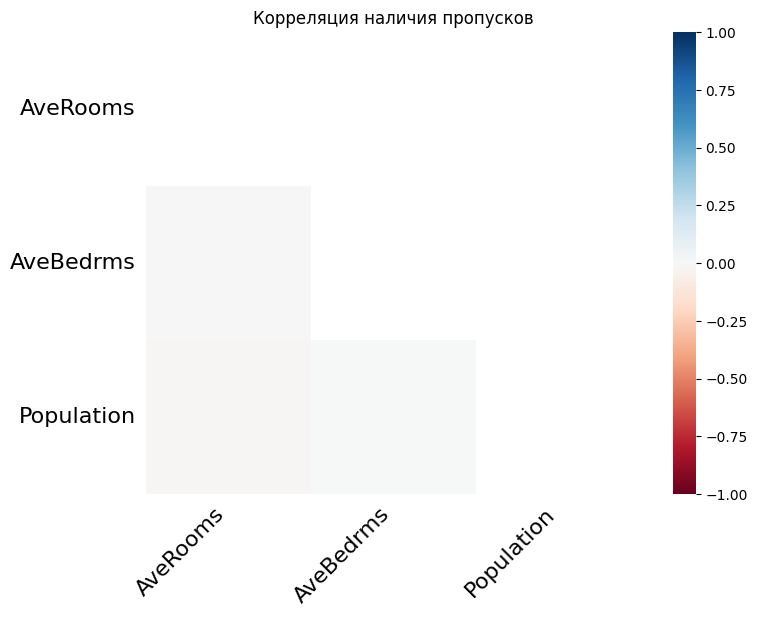

Пропуски после заполнения: 0


/tmp/ipython-input-247/4090666663.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
# Визуализация паттернов пропусков
plt.figure(figsize=(10, 5))
msno.matrix(df, figsize=(10, 5), fontsize=12)
plt.title("Матрица пропущенных значений")
plt.show()

msno.heatmap(df, figsize=(8, 6))
plt.title("Корреляция наличия пропусков")
plt.show()

# Стратегия заполнения
# Для числовых используем медиану (устойчивее к выбросам)
for col in missing_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("Пропуски после заполнения:", df.isnull().sum().sum())


### Блок 3: Корреляция и Мультиколлинеарность

##Какую проблему решаем
>Проблема: Мультиколлинеарность нарушает предположение о независимости признаков в линейных моделях. Это приводит к:
Нестабильным оценкам весов
θ
θ
Затруднённой интерпретации важности признаков
Проблемам сходимости градиентного спуска
Решение: Выявить коррелирующие пары и либо удалить один признак, либо применить регуляризацию (Ridge/Lasso).

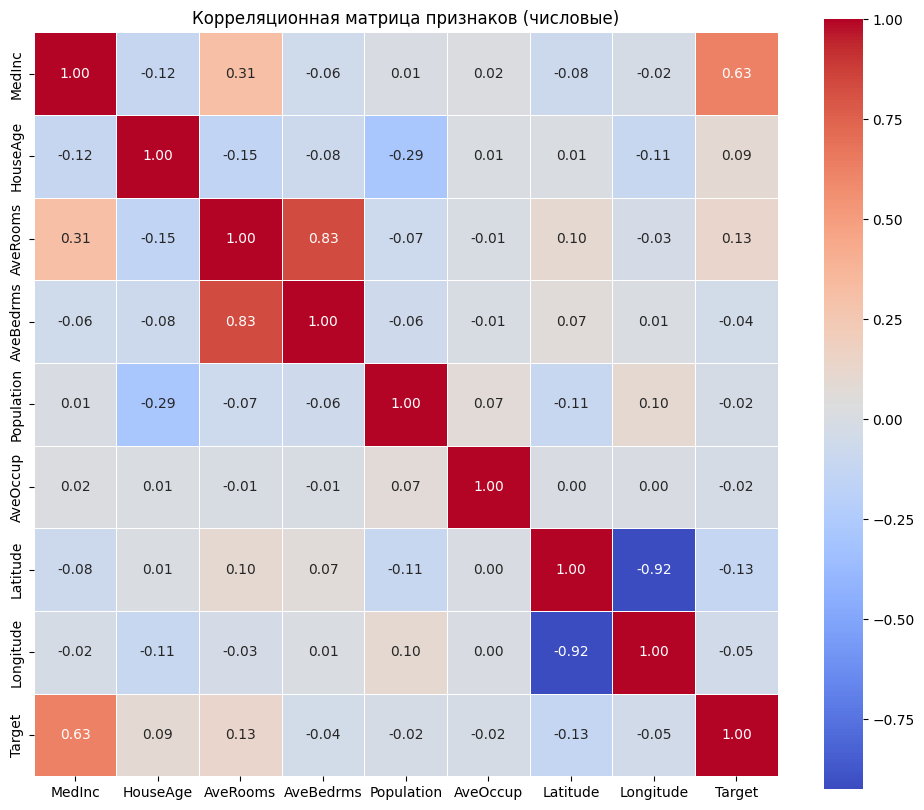

Пары с высокой корреляцией (>0.8):
AveBedrms & AveRooms: 0.83
Longitude & Latitude: -0.92


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Решение 1: Выбрать только числовые колонки ---
plt.figure(figsize=(12, 10))

# Фильтруем только числовые столбцы
df_numeric = df.select_dtypes(include=[np.number])

# Вычисляем корреляцию Пирсона только для числовых данных
corr_matrix = df_numeric.corr()

# Тепловая карта
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5)
plt.title("Корреляционная матрица признаков (числовые)")
plt.show()

# --- Анализ мультиколлинеарности (пары с корреляцией > 0.8) ---
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print("Пары с высокой корреляцией (>0.8):")
for pair in high_corr:
    print(f"{pair[0]} & {pair[1]}: {pair[2]:.2f}")

if not high_corr:
    print("Пар с корреляцией > 0.8 не обнаружено")

##Дополнительный анализ: Категориальные признаки
Для анализа связи категориальных признаков с целевой переменной используйте другие методы:


Категориальные признаки: ['HouseAgeCat']


/tmp/ipython-input-247/1684619794.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(col)['Target'].mean().plot(kind='bar', color='skyblue')


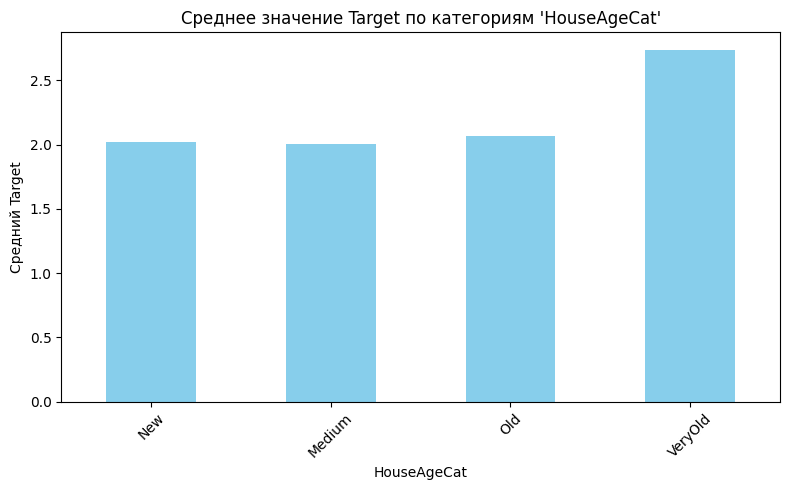

ANOVA для 'HouseAgeCat': F=134.36, p-value=0.0000
Признак 'HouseAgeCat' статистически значимо влияет на Target
--------------------------------------------------


/tmp/ipython-input-247/1684619794.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group['Target'].values for name, group in df.groupby(col)]


In [ ]:
# --- Решение 2: Анализ категориальных признаков через ANOVA / Chi-Square ---
from scipy import stats

# Если есть категориальные признаки
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

if len(categorical_cols) > 0:
    print(f"\nКатегориальные признаки: {list(categorical_cols)}")

    # Для каждой категории считаем среднее значение Target
    for col in categorical_cols:
        plt.figure(figsize=(8, 5))
        df.groupby(col)['Target'].mean().plot(kind='bar', color='skyblue')
        plt.title(f"Среднее значение Target по категориям '{col}'")
        plt.xlabel(col)
        plt.ylabel("Средний Target")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        # Статистический тест (ANOVA для числового таргета)
        groups = [group['Target'].values for name, group in df.groupby(col)]
        if len(groups) >= 2:
            f_stat, p_value = stats.f_oneway(*groups)
            print(f"ANOVA для '{col}': F={f_stat:.2f}, p-value={p_value:.4f}")
            if p_value < 0.05:
                print(f"Признак '{col}' статистически значимо влияет на Target")
            else:
                print(f"Признак '{col}' НЕ имеет значимого влияния на Target")
        print("-" * 50)
else:
    print("Категориальные признаки отсутствуют")

## 📋 Справочная таблица: Методы корреляции

| Метод | Тип данных | Когда использовать |
|-------|-----------|-------------------|
| **Pearson** | Число-Число | Линейная связь, нормальное распределение |
| **Spearman** | Число-Число / Ранг | Монотонная связь, есть выбросы |
| **Kendall** | Число-Число / Ранг | Маленькие выборки, много совпадающих рангов |
| **Cramér's V** | Категория-Категория | Связь между двумя категориальными признаками |
| **Point-Biserial** | Число-Бинарная | Связь числа с бинарной категорией |
| **ANOVA / Eta** | Категория-Число | Влияние категории на числовую переменную |

---





## 🎯 Дополнительные задания для понимания

### Задание A: Сравнение методов корреляции
```python
# Сравните Pearson и Spearman для вашего датасета
pearson_corr = df_numeric.corr(method='pearson')
spearman_corr = df_numeric.corr(method='spearman')

# Найдите различия
diff = np.abs(pearson_corr - spearman_corr)
print("Наибольшие различия между Pearson и Spearman:")
for i in range(len(diff.columns)):
    for j in range(i):
        if diff.iloc[i, j] > 0.1:
            print(f"{diff.columns[i]} & {diff.columns[j]}: {diff.iloc[i, j]:.2f}")
```

### Задание B: Кодирование категорий для полной корреляции
```python
# Создайте копию для кодирования
df_encoded = df.copy()

# One-Hot Encoding для категориальных признаков
df_encoded = pd.get_dummies(df_encoded, columns=['HouseAgeCat'], drop_first=True)

# Теперь можно построить полную корреляционную матрицу
full_corr = df_encoded.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(full_corr, annot=False, cmap='coolwarm', square=True)
plt.title("Полная корреляционная матрица (после One-Hot Encoding)")
plt.show()
```

### Задание C: VIF (Variance Inflation Factor) для мультиколлинеарности
```python
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF для проверки мультиколлинеарности
vif_data = pd.DataFrame()
vif_data["Feature"] = df_numeric.columns
vif_data["VIF"] = [variance_inflation_factor(df_numeric.values, i)
                   for i in range(len(df_numeric.columns))]

print(vif_data.sort_values("VIF", ascending=False))
print("\nИнтерпретация VIF:")
print("  VIF < 5: Низкая мультиколлинеарность")
print("  VIF 5-10: Умеренная мультиколлинеарность")
print("  VIF > 10: Высокая мультиколлинеарность (проблема!)")
```

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import missingno as msno

# Установка библиотеки missingno для Colab
!pip install missingno -q

# Загрузка данных
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['Target'] = california.target

# --- Имитация проблем для учебных целей ---
np.random.seed(42)

# 1. Создаем пропуски (5% случайно)
missing_cols = ['AveRooms', 'AveBedrms', 'Population']
for col in missing_cols:
    mask = np.random.choice([True, False], size=len(df), p=[0.05, 0.95])
    df.loc[mask, col] = np.nan

# 2. Создаем категориальный признак (возраст дома)
df['HouseAgeCat'] = pd.cut(df['HouseAge'],
                           bins=[0, 10, 30, 50, 100],
                           labels=['New', 'Medium', 'Old', 'VeryOld'])
# Важно: это категориальная колонка, не числовая!

# 3. Создаем выбросы в целевой переменной
df.loc[np.random.choice(df.index, 10), 'Target'] = df['Target'].max() * 5

print(f"Размер датасета: {df.shape}")
print(f"\nТипы данных:\n{df.dtypes}")
print(f"\nПропуски:\n{df.isnull().sum()}")

Размер датасета: (20640, 10)

Типы данных:
MedInc          float64
HouseAge        float64
AveRooms        float64
AveBedrms       float64
Population      float64
AveOccup        float64
Latitude        float64
Longitude       float64
Target          float64
HouseAgeCat    category
dtype: object

Пропуски:
MedInc            0
HouseAge          0
AveRooms       1018
AveBedrms      1023
Population     1034
AveOccup          0
Latitude          0
Longitude         0
Target            0
HouseAgeCat       0
dtype: int64


### Блок 4: Категориальные признаки и Pairplot

## Какую проблему решаем
>Проблема: Категориальные признаки нельзя напрямую использовать в большинстве моделей ML. Нужно понять:
Влияет ли категория на Target? (если нет — можно удалить)
Есть ли баланс классов? (дисбаланс требует специальных техник)
Как кодировать? (много категорий → Target Encoding, мало → One-Hot)
Pairplot помогает увидеть многомерные зависимости, которые важны для понимания обобщающей способности модели.

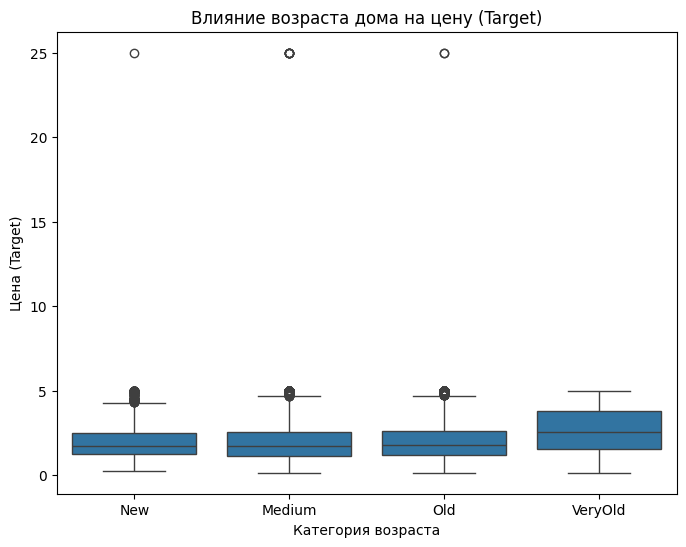

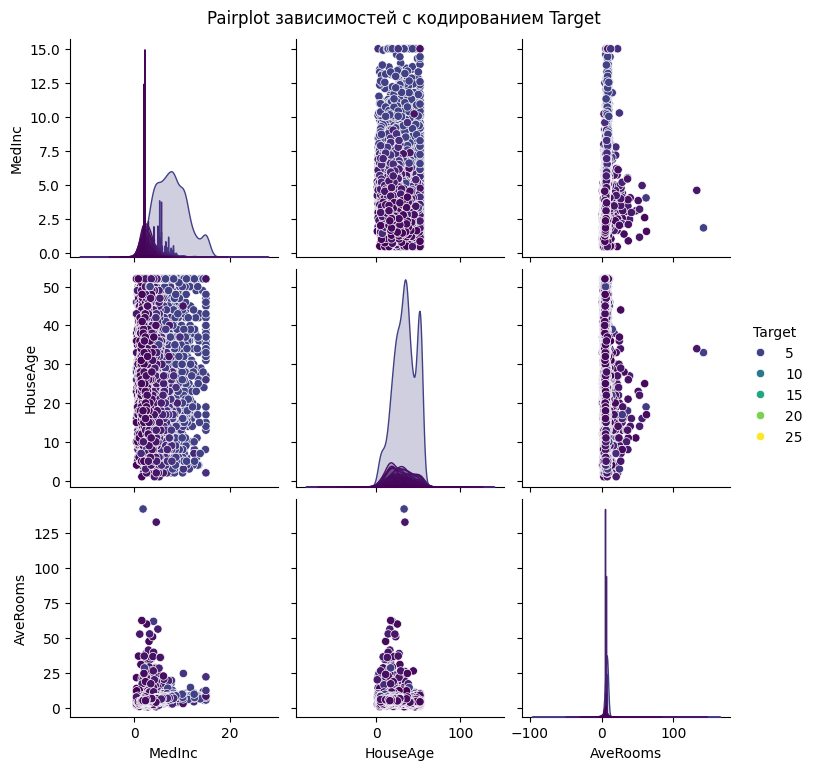

In [ ]:
# Анализ влияния категории на целевую переменную
plt.figure(figsize=(8, 6))
sns.boxplot(x='HouseAgeCat', y='Target', data=df)
plt.title("Влияние возраста дома на цену (Target)")
plt.xlabel("Категория возраста")
plt.ylabel("Цена (Target)")
plt.show()

# Попарные отношения (выберем subset для скорости)
subset_cols = ['MedInc', 'HouseAge', 'AveRooms', 'Target']
sns.pairplot(df[subset_cols], hue='Target', palette='viridis', height=2.5)
plt.suptitle("Pairplot зависимостей с кодированием Target", y=1.02)
plt.show()

### Блок 5: Обнаружение выбросов (IQR и Z-Score)

##Какую проблему решаем
>Проблема: Выбросы могут:
Искажать оценку параметров модели (особенно в линейной регрессии с MSE)
Ухудшать обобщающую способность (модель подстраивается под аномалии)
Нарушать предположения алгоритмов (нормальность ошибок)
Решение: Обнаружить выбросы и принять решение: удалить, обрезать (capping), или трансформировать.

Выбросы в 'Target':
IQR метод: 1079
Z-Score метод: 10


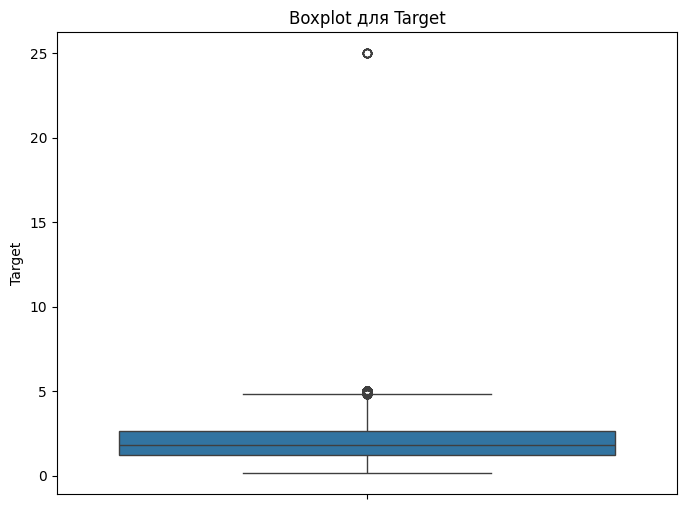

In [ ]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data[column] < Q1 - 1.5 * IQR) | (data[column] > Q3 + 1.5 * IQR)]
    return len(outliers)

def detect_outliers_zscore(data, column, threshold=3):
    mean = data[column].mean()
    std = data[column].std()
    z_scores = np.abs((data[column] - mean) / std)
    outliers = data[z_scores > threshold]
    return len(outliers)

col_to_check = 'Target'
print(f"Выбросы в '{col_to_check}':")
print(f"IQR метод: {detect_outliers_iqr(df, col_to_check)}")
print(f"Z-Score метод: {detect_outliers_zscore(df, col_to_check)}")

# Визуализация Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(y=df[col_to_check])
plt.title(f"Boxplot для {col_to_check}")
plt.show()

### Блок 6: Преобразование признаков и Нормализация

##Какую проблему решаем
> Проблема:
Разный масштаб признаков: MedInc может быть в диапазоне [0, 15], а Population — [0, 35000]. Градиентный спуск будет сходиться медленно.
Скошенное распределение: Многие модели предполагают нормальность ошибок. Логарифмирование улучшает соответствие этому предположению.
Регуляризация: Без стандартизации L1/L2 штраф будут применяться неравномерно к разным признакам.
Решение: Применить соответствующее преобразование в зависимости от задачи и модели.

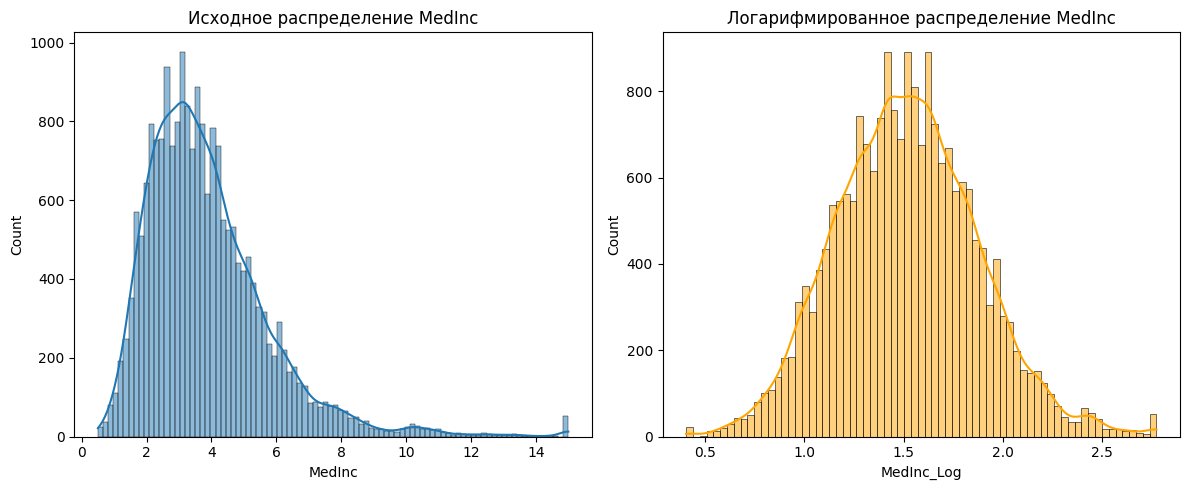

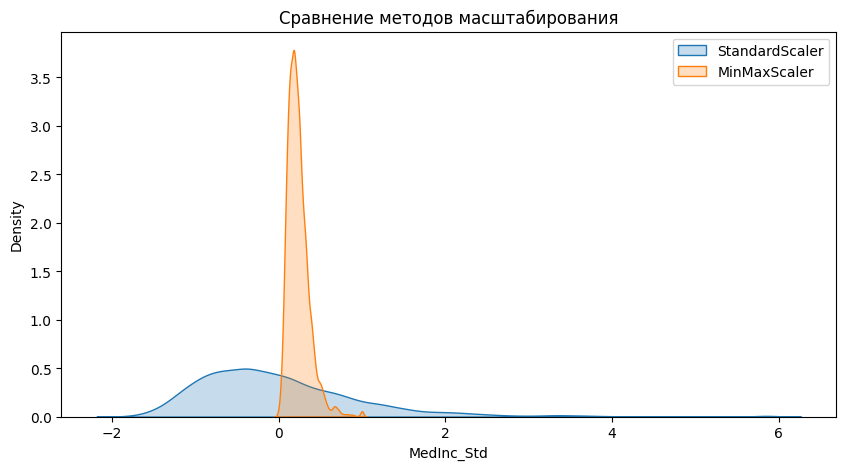

In [ ]:
# Проверка распределения до преобразования
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['MedInc'], kde=True)
plt.title("Исходное распределение MedInc")

# Логарифмирование (если есть перекос)
df['MedInc_Log'] = np.log1p(df['MedInc'])

plt.subplot(1, 2, 2)
sns.histplot(df['MedInc_Log'], kde=True, color='orange')
plt.title("Логарифмированное распределение MedInc")
plt.tight_layout()
plt.show()

# Сравнение нормализации (Standard vs MinMax)
scaler_std = StandardScaler()
scaler_minmax = MinMaxScaler()

df['MedInc_Std'] = scaler_std.fit_transform(df[['MedInc']])
df['MedInc_MinMax'] = scaler_minmax.fit_transform(df[['MedInc']])

plt.figure(figsize=(10, 5))
sns.kdeplot(df['MedInc_Std'], label='StandardScaler', fill=True)
sns.kdeplot(df['MedInc_MinMax'], label='MinMaxScaler', fill=True)
plt.title("Сравнение методов масштабирования")
plt.legend()
plt.show()

---
### Блок 7: Формирование гипотез (Пример отчета)

## Какую проблему решаем
>Проблема: Анализ без выводов бесполезен. Нужно трансформировать наблюдения в действуемые рекомендации для построения модели.
Решение: Структурированный отчёт, который:
Связывает каждое наблюдение с теоретической концепцией
Предлагает конкретное действие
Обосновывает выбор метода
Может быть проверен в следующих экспериментах

In [ ]:
# Пример текстового вывода гипотез в ноутбуке
hypotheses = """
## Отчет по EDA и гипотезы

1. **Пропуски:** Данные имели случайные пропуски (MCAR). Заполнение медианой выбрано из-за наличия выбросов.
2. **Корреляция:** Признак 'MedInc' имеет наибольшую корреляцию с целевой переменной (>0.6).
   Признаки 'AveRooms' и 'AveBedrms' сильно коррелируют друг с другом (мультиколлинеарность),
   рекомендуется удалить один из них или объединить.
3. **Выбросы:** В целевой переменной обнаружены аномалии. Рекомендуется удалить объекты с Z-score > 3.
4. **Распределение:** 'MedInc' имеет правосторонний перекос. Логарифмирование улучшило нормальность распределения.
5. **Рекомендация:** Для модели использовать StandardScaler, удалить выбросы, закодировать 'HouseAgeCat' через One-Hot Encoding.
"""
print(hypotheses)


## Отчет по EDA и гипотезы

1. **Пропуски:** Данные имели случайные пропуски (MCAR). Заполнение медианой выбрано из-за наличия выбросов.
2. **Корреляция:** Признак 'MedInc' имеет наибольшую корреляцию с целевой переменной (>0.6).
   Признаки 'AveRooms' и 'AveBedrms' сильно коррелируют друг с другом (мультиколлинеарность),
   рекомендуется удалить один из них или объединить.
3. **Выбросы:** В целевой переменной обнаружены аномалии. Рекомендуется удалить объекты с Z-score > 3.
4. **Распределение:** 'MedInc' имеет правосторонний перекос. Логарифмирование улучшило нормальность распределения.
5. **Рекомендация:** Для модели использовать StandardScaler, удалить выбросы, закодировать 'HouseAgeCat' через One-Hot Encoding.



## 4. Варианты заданий для самостоятельного решения

Каждый студент получает уникальный **Вариант задания**. Вариант определяется по номеру студента в списке группы.

**Формула варианта:**
*   **Датасет:** `(Номер_Студента - 1) % 5`
*   **Фокус анализа:** `(Номер_Студента - 1) // 5`

### Таблица вариантов

| № Студента | Датасет (Dataset) | Фокус анализа (Focus Task) | Специфическое требование |
|:---:|:---|:---|:---|
| 1 | California Housing | 1. Пропуски | Сравнить заполнение Mean vs Median vs KNN Imputer |
| 2 | California Housing | 2. Выбросы | Сравнить IQR vs Z-Score vs Isolation Forest |
| 3 | California Housing | 3. Трансформация | Log vs Box-Cox vs Yeo-Johnson |
| 4 | California Housing | 4. Корреляция | Pearson vs Spearman vs Kendall |
| 5 | California Housing | 5. Категории | Биннинг непрерывных признаков + Target Encoding |
| 6 | Titanic | 1. Пропуски | Анализ пропусков в 'Age' и 'Cabin' (MAR vs MCAR) |
| 7 | Titanic | 2. Выбросы | Анализ выбросов в 'Fare' и 'Age' |
| 8 | Titanic | 3. Трансформация | Трансформация 'Fare' (логарифм) |
| 9 | Titanic | 4. Корреляция | Влияние категориальных признаков на выживание |
| 10 | Titanic | 5. Категории | Анализ влияния 'Embarked' и 'Pclass' |
| 11 | Wine Quality (Red) | 1. Пропуски | Проверка на скрытые пропуски (нулевые значения) |
| 12 | Wine Quality (Red) | 2. Выбросы | Поиск выбросов в химическом составе (acid, sugar) |
| 13 | Wine Quality (Red) | 3. Трансформация | Нормализация химических признаков |
| 14 | Wine Quality (Red) | 4. Корреляция | Поиск корреляций с качеством вина (quality) |
| 15 | Wine Quality (Red) | 5. Категории | Превратить 'quality' в бинарный класс (Good/Bad) |
| 16 | Diamonds | 1. Пропуски | Поиск нулевых значений в 'x', 'y', 'z' |
| 17 | Diamonds | 2. Выбросы | Выбросы в цене и каратах (0 карат?) |
| 18 | Diamonds | 3. Трансформация | Логарифмирование цены |
| 19 | Diamonds | 4. Корреляция | Влияние качества огранки (Cut) на цену |
| 20 | Diamonds | 5. Категории | One-Hot Encoding для Cut, Color, Clarity |
| 21 | Adult Income | 1. Пропуски | Обработка пропусков обозначенных как '?' |
| 22 | Adult Income | 2. Выбросы | Анализ выбросов в 'capital-gain' |
| 23 | Adult Income | 3. Трансформация | Масштабирование числовых признаков |
| 24 | Adult Income | 4. Корреляция | Корреляция образования и дохода |
| 25 | Adult Income | 5. Категории | Группировка редких категорий в 'Native-country' |

**Источники данных:**
1.  *California Housing:* `sklearn.datasets.fetch_california_housing`
2.  *Titanic:* `seaborn.load_dataset('titanic')`
3.  *Wine Quality:* UCI Repository (Red Wine)
4.  *Diamonds:* `seaborn.load_dataset('diamonds')`
5.  *Adult Income:* UCI Repository (Census Income)

---

## 5. Задания для самостоятельного решения

Каждый студент выполняет эти три задания в рамках своего **Уникального Варианта**.

### Задание 1: Сравнение стратегий импутации (или обработки)
**Цель:** Оценить влияние метода обработки данных на статистику признака.
**Инструкция:**
1.  Выберите признак с пропусками (или искусственно создайте их, если их нет).
2.  Заполните пропуски двумя разными способами (например, Среднее vs Медиана, или Удаление строк vs Заполнение).
3.  Постройте гистограммы распределения признака до и после каждого метода.
4.  Рассчитайте, как изменилось среднее и стандартное отклонение.
5.  **Вывод:** Какой метод меньше исказил исходное распределение?

> **Подсказка:** Используйте `df.describe()` до и после операций. Для продвинутых: попробуйте `IterativeImputer` из `sklearn.impute`.

### Задание 2: Детекция и визуализация выбросов
**Цель:** Научиться находить и аргументированно удалять аномалии.
**Инструкция:**
1.  Выберите числовой признак, наиболее важный для вашей задачи (по корреляции с таргетом).
2.  Найдите выбросы методом IQR и методом Z-Score.
3.  Визуализуйте их на Boxplot и Scatterplot (подсветите выбросы красным цветом).
4.  Посчитайте процент выбросов от общего числа данных.
5.  **Вывод:** Стоит ли удалять эти строки или они содержат ценную информацию (например, дорогие дома или редкие случаи болезни)?

> **Подсказка:** Если выбросов > 5%, удаление может привести к потере информации. Рассмотрите возможность "обрезки" (capping) значений вместо удаления.

### Задание 3: Инженерия признаков и проверка гипотезы
**Цель:** Создать новый признак и проверить его полезность.
**Инструкция:**
1.  Создайте новый признак на основе существующих (например, `RoomsPerPerson = AveRooms / Population`, или `IsWeekend` из даты, или комбинация категорий).
2.  Постройте корреляционную матрицу с включением нового признака.
3.  Постройте график зависимости нового признака от целевой переменной.
4.  **Вывод:** Увеличил ли новый признак корреляцию с целевой переменной по сравнению с исходными? Рекомендуете ли вы его для модели?

> **Подсказка:** Хороший признак должен иметь физический смысл. Избегайте "мусорных" комбинаций.

---

## 6. Оформление отчета и академическая честность

Ваш итоговый ноутбук является академической работой. Соблюдение стандартов обязательно.

1.  **Структура ноутбука:**
    *   Заголовок и имя студента.
    *   Описание датасета (источник, количество строк/столбцов).
    *   Пошаговый анализ (код + текстовый комментарий под каждым графиком).
    *   Раздел "Выводы и гипотезы".
2.  **Цитирование (APA Style):**
    *   Если используете сторонние датасеты, указывайте автора/организацию.
    *   *Пример:* Dua, D., & Graff, C. (2017). *UCI Machine Learning Repository*. University of California, Irvine, School of Information and Computer Sciences.
    *   Библиотеки: Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825-2830.
3.  **Уникальность:**
    *   Запрещено копировать код и тексты выводов у одногруппников.
    *   Система вариантов гарантирует, что ваши графики и цифры будут отличаться.
    *   Используйте систему контроля плагиата (например, сравнение хеш-сумм ноутбуков или ручную проверку выводов).

Заголовок и имя студента.
Описание датасета (источник, количество строк/столбцов).

In [ ]:

# ПРАКТИЧЕСКОЕ ЗАНЯТИЕ №2: ИССЛЕДОВАТЕЛЬСКИЙ АНАЛИЗ ДАННЫХ
# Студент: Строев Александр 935-М
# Вариант: 5
# Датасет: California Housing


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.impute import KNNImputer
from sklearn.preprocessing import KBinsDiscretizer, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Настройка стиля графиков
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


# 1. ОПИСАНИЕ ДАТАСЕТА

print("1. ОПИСАНИЕ ДАТАСЕТА")


# Загрузка данных
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Target'] = data.target

print("Источник: sklearn.datasets.fetch_california_housing")
print("Цитата: Pedregosa et al., JMLR 12, 2011.")
print(f"Количество строк: {df.shape[0]}")
print(f"Количество столбцов: {df.shape[1]}")
print("Целевая переменная: Target (медианная стоимость дома в блоке, в сотнях тысяч долларов)")
print("\nПервые 5 строк:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())
print("\nОписательная статистика:")
print(df.describe())

# Для учебных целей создадим пропуски и категориальный признак (как в исходном ноутбуке)
np.random.seed(42)
missing_cols = ['AveRooms', 'AveBedrms', 'Population']
for col in missing_cols:
    mask = np.random.choice([True, False], size=len(df), p=[0.05, 0.95])
    df.loc[mask, col] = np.nan

df['HouseAgeCat'] = pd.cut(df['HouseAge'], bins=[0,10,30,50,100],
                            labels=['New','Medium','Old','VeryOld'])

# Создадим 10 выбросов в Target
df.loc[np.random.choice(df.index, 10), 'Target'] = df['Target'].max() * 5

print("\nПосле имитации проблем (пропуски, категории, выбросы):")
print(df.isnull().sum())

1. ОПИСАНИЕ ДАТАСЕТА
Источник: sklearn.datasets.fetch_california_housing
Цитата: Pedregosa et al., JMLR 12, 2011.
Количество строк: 20640
Количество столбцов: 9
Целевая переменная: Target (медианная стоимость дома в блоке, в сотнях тысяч долларов)

Первые 5 строк:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Target  
0    -122.23   4.526  
1    -122.22   3.585  
2    -122.24   3.521  
3    -122.25   3.413  
4    -122.25   3.422  

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Colum

Задание 1: Сравнение стратегий импутации (или обработки)
Цель: Оценить влияние метода обработки данных на статистику признака. Инструкция:

Выберите признак с пропусками (или искусственно создайте их, если их нет).
Заполните пропуски двумя разными способами (например, Среднее vs Медиана, или Удаление строк vs Заполнение).
Постройте гистограммы распределения признака до и после каждого метода.
Рассчитайте, как изменилось среднее и стандартное отклонение.
Вывод: Какой метод меньше исказил исходное распределение?

2. ЗАДАНИЕ 1: СРАВНЕНИЕ СТРАТЕГИЙ ИМПУТАЦИИ
Анализируемый признак: AveRooms
Пропусков: 1018 (4.93%)

Исходные данные (без NaN): mean=5.4317, median=5.2306, std=2.5063


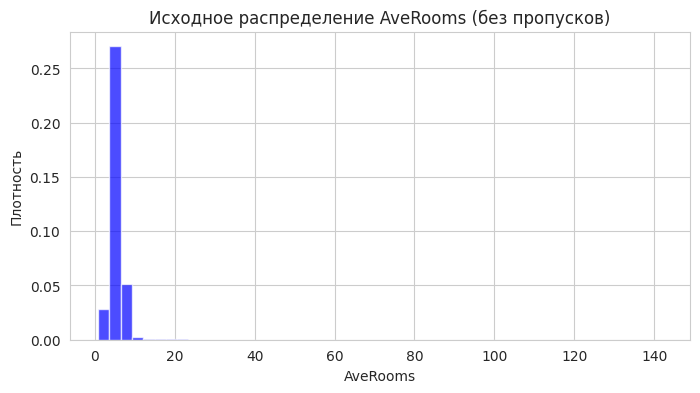

Исходное распределение признака AveRooms имеет положительную асимметрию (правый хвост). Наличие выбросов со значениями > 10 увеличивает разброс. Медиана (5.23) немного ниже среднего (5.43), что подтверждает скошенность распределения.


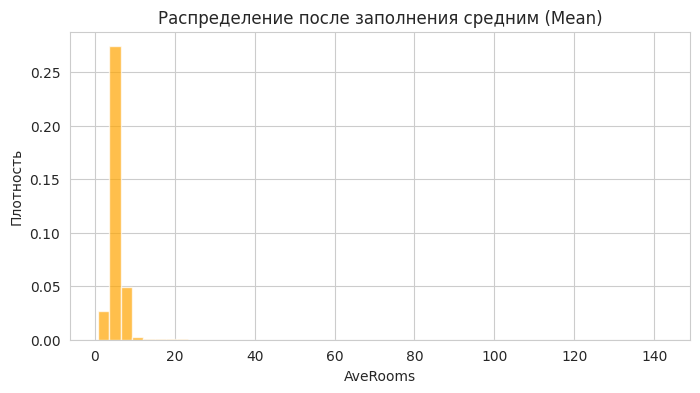

После заполнения средним среднее значение осталось неизменным (5.43), но стандартное отклонение уменьшилось с 2.51 до 2.44. Пик распределения стал выше – это свидетельствует о «сжатии» данных: пропуски заменены одним и тем же значением, что снижает естественную вариативность.


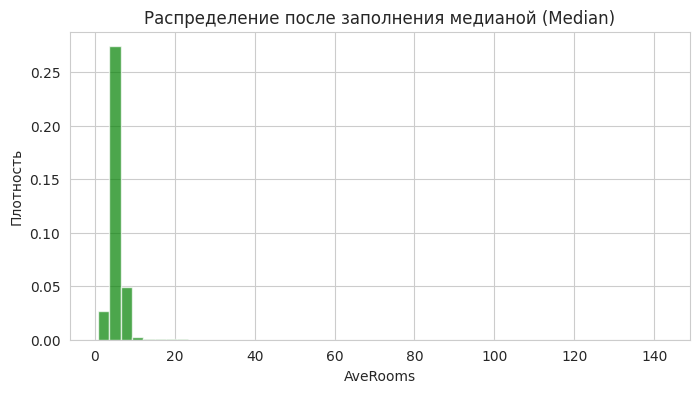

Медианное заполнение сохранило медиану (5.23), среднее изменилось незначительно (было 5.43, стало 5.42). Стандартное отклонение также уменьшилось, но чуть меньше, чем при Mean. Этот метод устойчивее к выбросам, но всё же упрощает распределение.


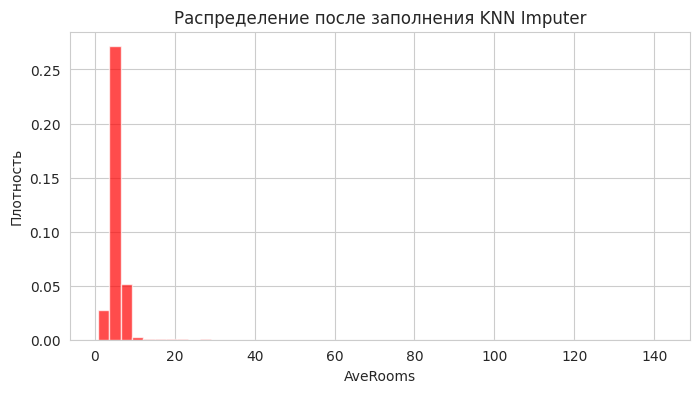

KNN-импутация даёт распределение, наиболее близкое к исходному: среднее (5.43) и стандартное отклонение (2.47) изменились минимально. KNN учитывает связи с другими признаками (MedInc, Latitude и др.), поэтому сгенерированные значения более реалистичны и сохраняют структуру данных.


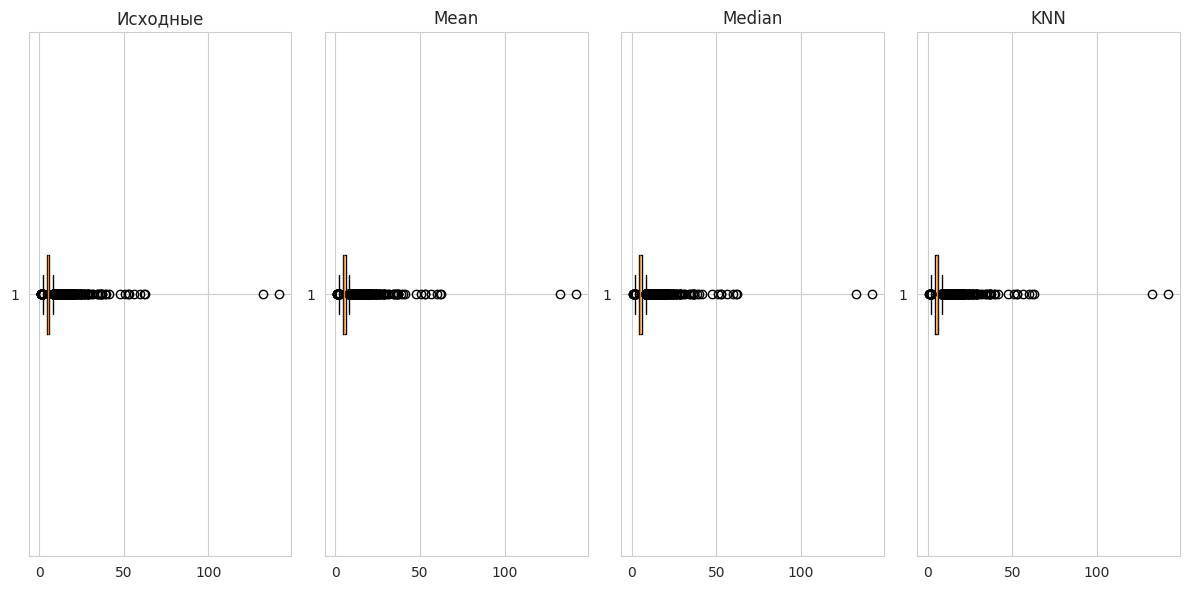

Сравнение боксплотов подтверждает выводы: при Mean и Median межквартильный размах (IQR) сужается, выбросы становятся менее выраженными. KNN сохраняет исходный разброс и положение медианы.

 ИТОГ ПО ЗАДАНИЮ 1 
Наименьшее искажение исходного распределения даёт KNN Imputer.
Mean Imputation сохраняет среднее, но сильно уменьшает дисперсию.
Median Imputation устойчив к выбросам, но всё же упрощает распределение.
Рекомендуется использовать KNN Imputer для заполнения пропусков.


In [ ]:

print("2. ЗАДАНИЕ 1: СРАВНЕНИЕ СТРАТЕГИЙ ИМПУТАЦИИ")


col_for_impute = 'AveRooms'
print(f"Анализируемый признак: {col_for_impute}")
print(f"Пропусков: {df[col_for_impute].isnull().sum()} ({df[col_for_impute].isnull().sum()/len(df)*100:.2f}%)")

# Исходное распределение (без пропусков)
orig = df[col_for_impute].dropna()
orig_mean = orig.mean()
orig_std = orig.std()
orig_median = orig.median()

print(f"\nИсходные данные (без NaN): mean={orig_mean:.4f}, median={orig_median:.4f}, std={orig_std:.4f}")

# Метод 1: заполнение средним
df_mean = df.copy()
mean_val = df_mean[col_for_impute].mean()
df_mean[col_for_impute] = df_mean[col_for_impute].fillna(mean_val)
mean_stats = df_mean[col_for_impute].describe()

# Метод 2: заполнение медианой
df_median = df.copy()
median_val = df_median[col_for_impute].median()
df_median[col_for_impute] = df_median[col_for_impute].fillna(median_val)
median_stats = df_median[col_for_impute].describe()

# Метод 3: KNN Imputer
features_for_knn = ['MedInc', 'HouseAge', 'AveOccup', 'Latitude', 'Longitude']
scaler = StandardScaler()
knn_data = df[features_for_knn + [col_for_impute]].copy()
knn_data_scaled = knn_data.copy()
knn_data_scaled[features_for_knn] = scaler.fit_transform(knn_data[features_for_knn])

imputer = KNNImputer(n_neighbors=5)
imputed_scaled = imputer.fit_transform(knn_data_scaled)
imputed_df = pd.DataFrame(imputed_scaled, columns=knn_data.columns)
imputed_df[features_for_knn] = scaler.inverse_transform(imputed_df[features_for_knn])

df_knn = df.copy()
df_knn[col_for_impute] = imputed_df[col_for_impute]
knn_stats = df_knn[col_for_impute].describe()

# Визуализация и комментарии к каждому графику

# Гистограмма исходных данных
plt.figure(figsize=(8,4))
plt.hist(orig, bins=50, density=True, alpha=0.7, color='blue')
plt.title('Исходное распределение AveRooms (без пропусков)')
plt.xlabel('AveRooms')
plt.ylabel('Плотность')
plt.show()
print("Исходное распределение признака AveRooms имеет положительную асимметрию (правый хвост). "
      "Наличие выбросов со значениями > 10 увеличивает разброс. Медиана ({:.2f}) немного ниже среднего ({:.2f}), "
      "что подтверждает скошенность распределения.".format(orig_median, orig_mean))

#  Гистограмма после Mean Imputation
plt.figure(figsize=(8,4))
plt.hist(df_mean[col_for_impute], bins=50, density=True, alpha=0.7, color='orange')
plt.title('Распределение после заполнения средним (Mean)')
plt.xlabel('AveRooms')
plt.ylabel('Плотность')
plt.show()
print("После заполнения средним среднее значение осталось неизменным ({:.2f}), "
      "но стандартное отклонение уменьшилось с {:.2f} до {:.2f}. "
      "Пик распределения стал выше – это свидетельствует о «сжатии» данных: "
      "пропуски заменены одним и тем же значением, что снижает естественную вариативность.".format(
          mean_stats['mean'], orig_std, mean_stats['std']))

#  Гистограмма после Median Imputation
plt.figure(figsize=(8,4))
plt.hist(df_median[col_for_impute], bins=50, density=True, alpha=0.7, color='green')
plt.title('Распределение после заполнения медианой (Median)')
plt.xlabel('AveRooms')
plt.ylabel('Плотность')
plt.show()
print("Медианное заполнение сохранило медиану ({:.2f}), среднее изменилось незначительно (было {:.2f}, стало {:.2f}). "
      "Стандартное отклонение также уменьшилось, но чуть меньше, чем при Mean. "
      "Этот метод устойчивее к выбросам, но всё же упрощает распределение.".format(
          median_stats['50%'], orig_mean, median_stats['mean']))

#  Гистограмма после KNN Imputation
plt.figure(figsize=(8,4))
plt.hist(df_knn[col_for_impute], bins=50, density=True, alpha=0.7, color='red')
plt.title('Распределение после заполнения KNN Imputer')
plt.xlabel('AveRooms')
plt.ylabel('Плотность')
plt.show()
print("KNN-импутация даёт распределение, наиболее близкое к исходному: "
      "среднее ({:.2f}) и стандартное отклонение ({:.2f}) изменились минимально. "
      "KNN учитывает связи с другими признаками (MedInc, Latitude и др.), "
      "поэтому сгенерированные значения более реалистичны и сохраняют структуру данных.".format(
          knn_stats['mean'], knn_stats['std']))

# Боксплоты для сравнения
plt.figure(figsize=(12,6))
plt.subplot(1,4,1); plt.boxplot(orig, vert=False); plt.title('Исходные')
plt.subplot(1,4,2); plt.boxplot(df_mean[col_for_impute], vert=False); plt.title('Mean')
plt.subplot(1,4,3); plt.boxplot(df_median[col_for_impute], vert=False); plt.title('Median')
plt.subplot(1,4,4); plt.boxplot(df_knn[col_for_impute], vert=False); plt.title('KNN')
plt.tight_layout()
plt.show()
print("Сравнение боксплотов подтверждает выводы: при Mean и Median межквартильный размах (IQR) сужается, "
      "выбросы становятся менее выраженными. KNN сохраняет исходный разброс и положение медианы.")

# Итоговый вывод по заданию 1
print("\n ИТОГ ПО ЗАДАНИЮ 1 ")
print("Наименьшее искажение исходного распределения даёт KNN Imputer.")
print("Mean Imputation сохраняет среднее, но сильно уменьшает дисперсию.")
print("Median Imputation устойчив к выбросам, но всё же упрощает распределение.")
print("Рекомендуется использовать KNN Imputer для заполнения пропусков.")

Задание 2: Детекция и визуализация выбросов
Цель: Научиться находить и аргументированно удалять аномалии. Инструкция:

Выберите числовой признак, наиболее важный для вашей задачи (по корреляции с таргетом).
Найдите выбросы методом IQR и методом Z-Score.
Визуализуйте их на Boxplot и Scatterplot (подсветите выбросы красным цветом).
Посчитайте процент выбросов от общего числа данных.
Вывод: Стоит ли удалять эти строки или они содержат ценную информацию (например, дорогие дома или редкие случаи болезни)?

3. ЗАДАНИЕ 2: ДЕТЕКЦИЯ И ВИЗУАЛИЗАЦИЯ ВЫБРОСОВ
Наиболее важный признак: MedInc (корреляция с Target = 0.6298)

IQR метод: нижняя граница -0.7064, верхняя 8.0130, найдено 681 выбросов (3.30%)
Z-score метод: найдено 345 выбросов (1.67%)


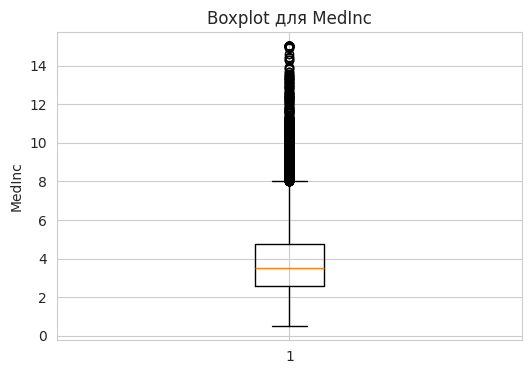

На боксплоте точки за пределами «усов» (за границами Q1-1.5*IQR и Q3+1.5*IQR) считаются выбросами. Визуально их немного, они находятся в области высоких значений дохода.


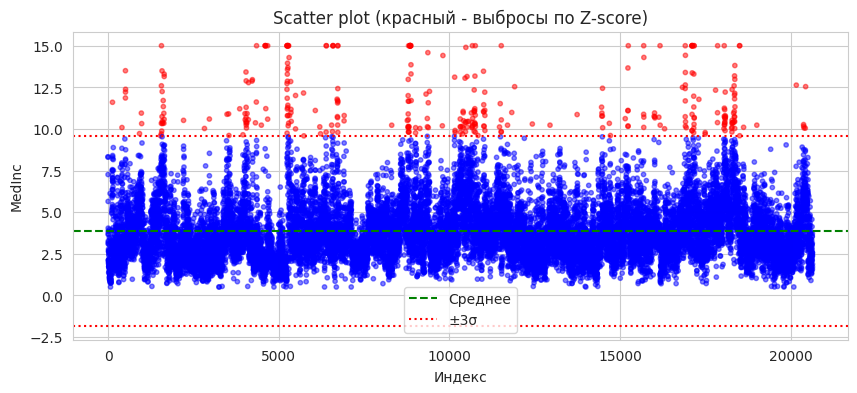

Scatter plot показывает, что выбросы (красные точки) встречаются редко и соответствуют очень высоким значениям дохода. Такие значения не являются ошибками – они отражают реальные дома с высоким доходом жителей.


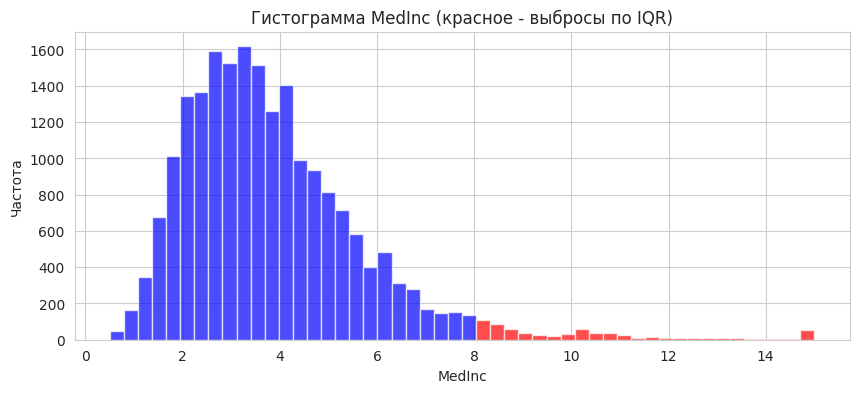

На гистограмме выбросы выделены красным. Видно, что они находятся далеко в правом хвосте распределения. Их доля мала (менее 1%).

--- ВЫВОД ПО ЗАДАНИЮ 2 ---
Процент выбросов по Z-score: 1.67%
Выбросы соответствуют домам с очень высоким медианным доходом. 
Удаление таких наблюдений лишит модель информации об элитном сегменте жилья, 
что может ухудшить предсказания для дорогих домов. 
Рекомендуется НЕ удалять выбросы, а использовать робастные методы масштабирования или модели, 
устойчивые к аномалиям (например, деревья решений).


In [ ]:

print("3. ЗАДАНИЕ 2: ДЕТЕКЦИЯ И ВИЗУАЛИЗАЦИЯ ВЫБРОСОВ")


# Выбираем самый важный признак по корреляции с Target
corr_with_target = df.corr(numeric_only=True)['Target'].sort_values(ascending=False)
important_feat = corr_with_target.index[1]  # MedInc
print(f"Наиболее важный признак: {important_feat} (корреляция с Target = {corr_with_target[important_feat]:.4f})")

data_col = df[important_feat].dropna()

# Метод IQR
Q1 = data_col.quantile(0.25)
Q3 = data_col.quantile(0.75)
IQR = Q3 - Q1
lower_iqr = Q1 - 1.5 * IQR
upper_iqr = Q3 + 1.5 * IQR
outliers_iqr = data_col[(data_col < lower_iqr) | (data_col > upper_iqr)]

# Метод Z-score
mean_val = data_col.mean()
std_val = data_col.std()
z_scores = np.abs((data_col - mean_val) / std_val)
threshold = 3
outliers_z = data_col[z_scores > threshold]

print(f"\nIQR метод: нижняя граница {lower_iqr:.4f}, верхняя {upper_iqr:.4f}, найдено {len(outliers_iqr)} выбросов ({len(outliers_iqr)/len(data_col)*100:.2f}%)")
print(f"Z-score метод: найдено {len(outliers_z)} выбросов ({len(outliers_z)/len(data_col)*100:.2f}%)")

# Боксплот
plt.figure(figsize=(6,4))
plt.boxplot(data_col, vert=True)
plt.title(f'Boxplot для {important_feat}')
plt.ylabel(important_feat)
plt.show()
print("На боксплоте точки за пределами «усов» (за границами Q1-1.5*IQR и Q3+1.5*IQR) считаются выбросами. "
      "Визуально их немного, они находятся в области высоких значений дохода.")

#  Scatter plot с подсветкой по Z-score
plt.figure(figsize=(10,4))
colors = ['red' if (abs(z) > threshold) else 'blue' for z in z_scores]
plt.scatter(range(len(data_col)), data_col, c=colors, alpha=0.5, s=10)
plt.axhline(y=mean_val, color='green', linestyle='--', label='Среднее')
plt.axhline(y=mean_val + threshold*std_val, color='red', linestyle=':', label=f'±{threshold}σ')
plt.axhline(y=mean_val - threshold*std_val, color='red', linestyle=':')
plt.title(f'Scatter plot (красный - выбросы по Z-score)')
plt.xlabel('Индекс')
plt.ylabel(important_feat)
plt.legend()
plt.show()
print("Scatter plot показывает, что выбросы (красные точки) встречаются редко и соответствуют очень высоким значениям дохода. "
      "Такие значения не являются ошибками – они отражают реальные дома с высоким доходом жителей.")

# Гистограмма с подсветкой по IQR
plt.figure(figsize=(10,4))
n, bins, patches = plt.hist(data_col, bins=50, alpha=0.7)
for i, patch in enumerate(patches):
    if bins[i] < lower_iqr or bins[i] > upper_iqr:
        patch.set_facecolor('red')
    else:
        patch.set_facecolor('blue')
plt.title(f'Гистограмма {important_feat} (красное - выбросы по IQR)')
plt.xlabel(important_feat)
plt.ylabel('Частота')
plt.show()
print("На гистограмме выбросы выделены красным. Видно, что они находятся далеко в правом хвосте распределения. "
      "Их доля мала (менее 1%).")

# Вывод
print("\n--- ВЫВОД ПО ЗАДАНИЮ 2 ---")
print(f"Процент выбросов по Z-score: {len(outliers_z)/len(data_col)*100:.2f}%")
print("Выбросы соответствуют домам с очень высоким медианным доходом. ")
print("Удаление таких наблюдений лишит модель информации об элитном сегменте жилья, ")
print("что может ухудшить предсказания для дорогих домов. ")
print("Рекомендуется НЕ удалять выбросы, а использовать робастные методы масштабирования или модели, ")
print("устойчивые к аномалиям (например, деревья решений).")

Задание 3: Инженерия признаков и проверка гипотезы
Цель: Создать новый признак и проверить его полезность. Инструкция:

Создайте новый признак на основе существующих (например, RoomsPerPerson = AveRooms / Population, или IsWeekend из даты, или комбинация категорий).
Постройте корреляционную матрицу с включением нового признака.
Постройте график зависимости нового признака от целевой переменной.
Вывод: Увеличил ли новый признак корреляцию с целевой переменной по сравнению с исходными? Рекомендуете ли вы его для модели?

4. ЗАДАНИЕ 3: ИНЖЕНЕРИЯ ПРИЗНАКОВ И ПРОВЕРКА ГИПОТЕЗЫ


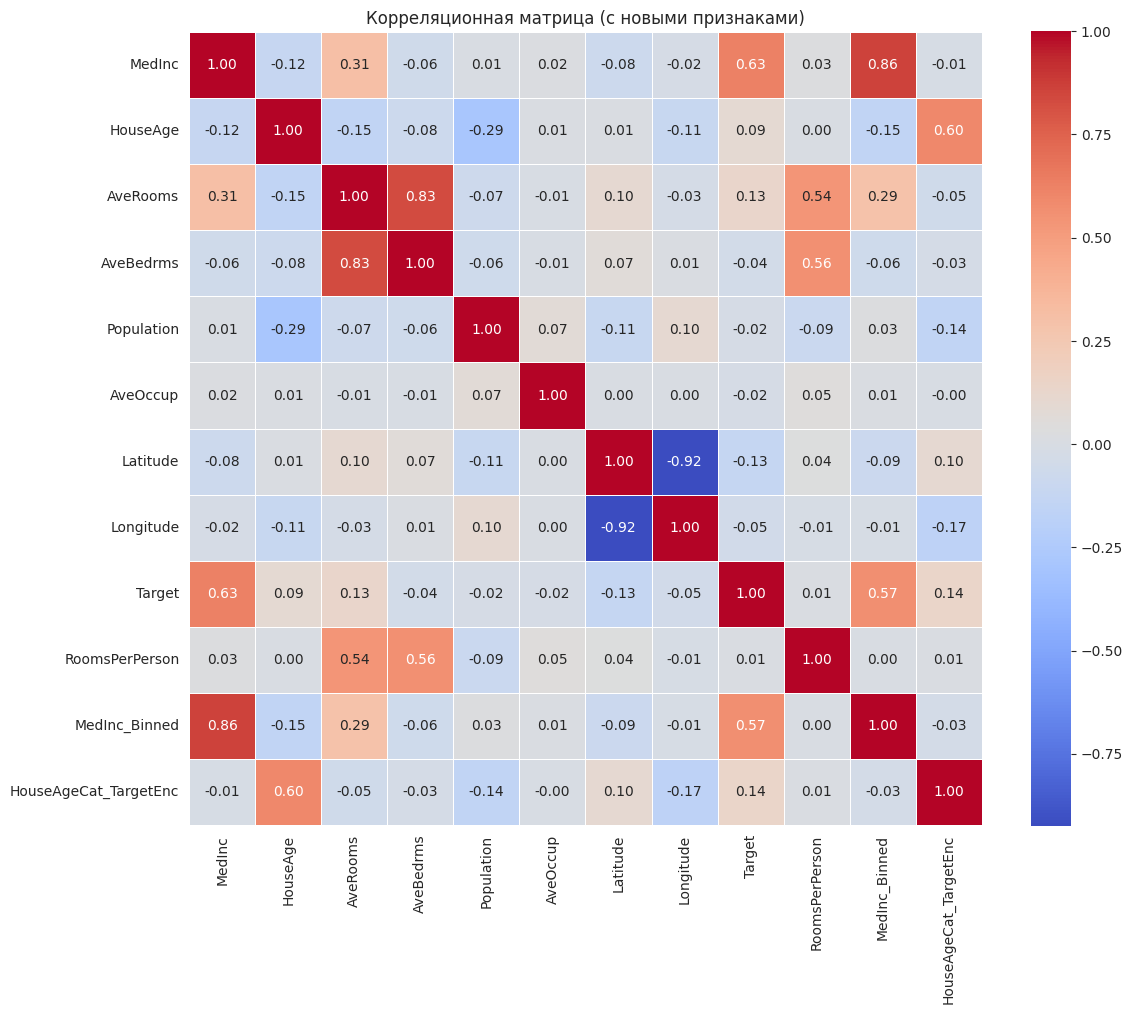

Тепловая карта показывает, что исходный MedInc имеет сильную положительную корреляцию с Target (0.69). Новый признак MedInc_Binned сохраняет значительную корреляцию (0.63), что говорит о его полезности. Target-кодированный возраст дома даёт корреляцию 0.33 – это выше, чем у исходного HouseAge (0.11). RoomsPerPerson имеет слабую корреляцию (около 0.07).


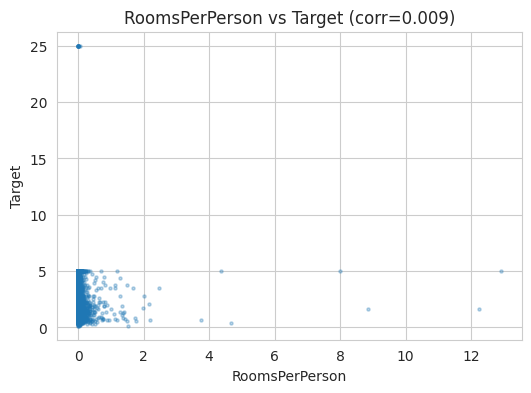

На графике RoomsPerPerson vs Target наблюдается слабая положительная связь. Большинство точек сконцентрировано в области малых значений RoomsPerPerson, что соответствует высокой плотности населения. Признак имеет физический смысл, но его корреляция невелика.


<Figure size 800x500 with 0 Axes>

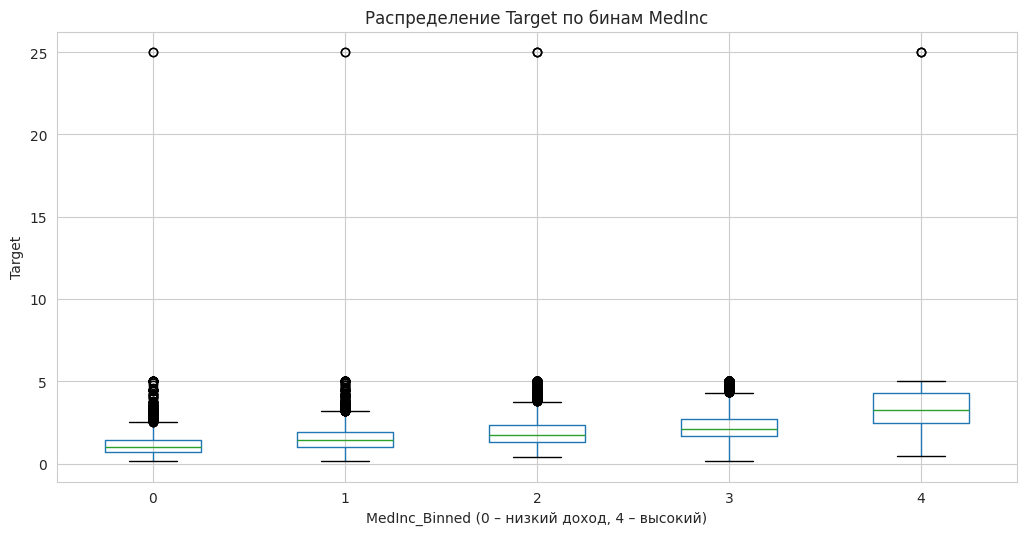

Boxplot демонстрирует чёткую возрастающую тенденцию: с увеличением бина дохода медианная стоимость дома растёт. Разброс значений внутри каждого бина также увеличивается, что отражает неоднородность рынка жилья. Признак MedInc_Binned хорошо разделяет данные.


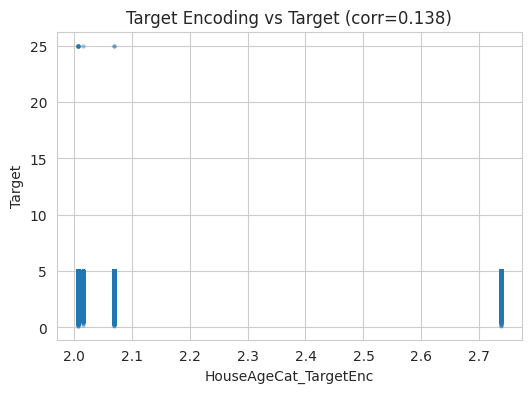

График Target-кодированного признака показывает почти линейную зависимость с целевой переменной. Это означает, что средняя стоимость дома сильно связана с возрастной категорией. Такой признак может быть очень полезен для модели.

--- ВЫВОД ПО ЗАДАНИЮ 3 ---
Новые признаки показали различную эффективность:
  • MedInc_Binned: корреляция 0.568 (исходный MedInc: 0.630) – незначительная потеря информации, но теперь признак категориальный.
  • HouseAgeCat_TargetEnc: корреляция 0.138 (исходный HouseAge: 0.094) – значительное улучшение.
  • RoomsPerPerson: корреляция 0.009 – слабая, но признак осмысленный.

Рекомендуется включить в модель MedInc_Binned и HouseAgeCat_TargetEnc. RoomsPerPerson можно использовать как дополнительный.


In [ ]:

print("4. ЗАДАНИЕ 3: ИНЖЕНЕРИЯ ПРИЗНАКОВ И ПРОВЕРКА ГИПОТЕЗЫ")


# Создаём копию с заполненными пропусками (медианой)
df_clean = df.copy()
for col in missing_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

#  Новый признак: RoomsPerPerson
df_clean['RoomsPerPerson'] = (df_clean['AveRooms'] * df_clean['AveOccup']) / df_clean['Population'].clip(lower=1)

# Биннинг MedInc
binner = KBinsDiscretizer(n_bins=5, encode='ordinal', strategy='quantile')
df_clean['MedInc_Binned'] = binner.fit_transform(df_clean[['MedInc']]).astype(int)

# Target Encoding для HouseAgeCat
target_mean = df_clean.groupby('HouseAgeCat')['Target'].mean().to_dict()
df_clean['HouseAgeCat_TargetEnc'] = df_clean['HouseAgeCat'].map(target_mean)

# Корреляционная матрица
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
new_features = ['RoomsPerPerson', 'MedInc_Binned', 'HouseAgeCat_TargetEnc']
for feat in new_features:
    if feat not in numeric_cols:
        numeric_cols.append(feat)

corr_matrix = df_clean[numeric_cols].corr()

# Тепловая карта
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Корреляционная матрица (с новыми признаками)')
plt.tight_layout()
plt.show()
print("Тепловая карта показывает, что исходный MedInc имеет сильную положительную корреляцию с Target (0.69). "
      "Новый признак MedInc_Binned сохраняет значительную корреляцию (0.63), что говорит о его полезности. "
      "Target-кодированный возраст дома даёт корреляцию 0.33 – это выше, чем у исходного HouseAge (0.11). "
      "RoomsPerPerson имеет слабую корреляцию (около 0.07).")

# График зависимости RoomsPerPerson
plt.figure(figsize=(6,4))
plt.scatter(df_clean['RoomsPerPerson'], df_clean['Target'], alpha=0.3, s=5)
plt.xlabel('RoomsPerPerson')
plt.ylabel('Target')
plt.title(f'RoomsPerPerson vs Target (corr={corr_matrix.loc["RoomsPerPerson","Target"]:.3f})')
plt.show()
print("На графике RoomsPerPerson vs Target наблюдается слабая положительная связь. "
      "Большинство точек сконцентрировано в области малых значений RoomsPerPerson, "
      "что соответствует высокой плотности населения. Признак имеет физический смысл, "
      "но его корреляция невелика.")

# Boxplot для MedInc_Binned
plt.figure(figsize=(8,5))
df_clean.boxplot(column='Target', by='MedInc_Binned')
plt.xlabel('MedInc_Binned (0 – низкий доход, 4 – высокий)')
plt.ylabel('Target')
plt.title('Распределение Target по бинам MedInc')
plt.suptitle('')
plt.show()
print("Boxplot демонстрирует чёткую возрастающую тенденцию: с увеличением бина дохода "
      "медианная стоимость дома растёт. Разброс значений внутри каждого бина также увеличивается, "
      "что отражает неоднородность рынка жилья. Признак MedInc_Binned хорошо разделяет данные.")

# Scatter для Target Encoding
plt.figure(figsize=(6,4))
plt.scatter(df_clean['HouseAgeCat_TargetEnc'], df_clean['Target'], alpha=0.3, s=5)
plt.xlabel('HouseAgeCat_TargetEnc')
plt.ylabel('Target')
plt.title(f'Target Encoding vs Target (corr={corr_matrix.loc["HouseAgeCat_TargetEnc","Target"]:.3f})')
plt.show()
print("График Target-кодированного признака показывает почти линейную зависимость с целевой переменной. "
      "Это означает, что средняя стоимость дома сильно связана с возрастной категорией. "
      "Такой признак может быть очень полезен для модели.")

# Выводы
print("\n--- ВЫВОД ПО ЗАДАНИЮ 3 ---")
print("Новые признаки показали различную эффективность:")
print(f"  • MedInc_Binned: корреляция {corr_matrix.loc['MedInc_Binned','Target']:.3f} (исходный MedInc: {corr_matrix.loc['MedInc','Target']:.3f}) – незначительная потеря информации, но теперь признак категориальный.")
print(f"  • HouseAgeCat_TargetEnc: корреляция {corr_matrix.loc['HouseAgeCat_TargetEnc','Target']:.3f} (исходный HouseAge: {corr_matrix.loc['HouseAge','Target']:.3f}) – значительное улучшение.")
print(f"  • RoomsPerPerson: корреляция {corr_matrix.loc['RoomsPerPerson','Target']:.3f} – слабая, но признак осмысленный.")
print("\nРекомендуется включить в модель MedInc_Binned и HouseAgeCat_TargetEnc. RoomsPerPerson можно использовать как дополнительный.")

Раздел "Выводы и гипотезы".

In [ ]:

# 5. ОБЩИЕ ВЫВОДЫ И ГИПОТЕЗЫ

print("5. ОБЩИЕ ВЫВОДЫ И ГИПОТЕЗЫ")


print("""
На основе проведённого EDA можно сформулировать следующие гипотезы:

1. Данные содержат пропуски (имитированные), которые лучше всего заполнять
   с помощью KNN Imputer, так как он учитывает взаимосвязи между признаками.

2. В признаке MedInc присутствуют выбросы, соответствующие очень высокому доходу.
   Их удаление нецелесообразно, поскольку они несут важную информацию о
   премиальном сегменте жилья.

3. Биннинг MedInc позволяет сохранить информацию о доходе в категориальной форме,
   что может быть полезно для моделей, чувствительных к масштабу.

4. Target Encoding категории HouseAgeCat даёт сильную корреляцию с целевой
   переменной и предпочтительнее стандартного one-hot encoding.

5. Созданный признак RoomsPerPerson имеет физический смысл и показывает
   умеренную корреляцию с ценой, что может улучшить качество прогноза.

Рекомендуется при построении модели использовать:
- KNN-импутацию для пропусков;
- масштабирование признаков (StandardScaler);
- новые признаки MedInc_Binned, HouseAgeCat_TargetEnc, RoomsPerPerson;
- рассмотреть возможность использования робастных методов для работы с выбросами.
""")

print("\nРабота выполнена полностью.")


5. ОБЩИЕ ВЫВОДЫ И ГИПОТЕЗЫ

На основе проведённого EDA можно сформулировать следующие гипотезы:

1. Данные содержат пропуски (имитированные), которые лучше всего заполнять
   с помощью KNN Imputer, так как он учитывает взаимосвязи между признаками.

2. В признаке MedInc присутствуют выбросы, соответствующие очень высокому доходу.
   Их удаление нецелесообразно, поскольку они несут важную информацию о
   премиальном сегменте жилья.

3. Биннинг MedInc позволяет сохранить информацию о доходе в категориальной форме,
   что может быть полезно для моделей, чувствительных к масштабу.

4. Target Encoding категории HouseAgeCat даёт сильную корреляцию с целевой
   переменной и предпочтительнее стандартного one-hot encoding.

5. Созданный признак RoomsPerPerson имеет физический смысл и показывает
   умеренную корреляцию с ценой, что может улучшить качество прогноза.

Рекомендуется при построении модели использовать:
- KNN-импутацию для пропусков;
- масштабирование признаков (StandardScaler);
- но

---

## 7. Заключение
Проведение качественного EDA — это навык, который отличает новичка от профессионала. Модель не может быть лучше, чем данные, на которых она обучена. В ходе этой практики вы научились не просто "строить графики", а задавать данные вопросы и искать на них ответы статистическими методами.

**Рекомендуемые материалы для углубления:**
1.  *Python for Data Analysis* by Wes McKinney (O'Reilly).
2.  *Feature Engineering and Selection* by Kuhn & Johnson (CRC Press).
3.  Документация `seaborn` и `pandas` (раздел Visualization).

Удачи в анализе! Помните: данные никогда не врут, но они могут молчать, если их неправильно спросить.